In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report

In [14]:
pip install seaborn --upgrade

^C
Note: you may need to restart the kernel to use updated packages.


In [2]:
#Load the dataset
#df = pd.read_csv("DiabetesDataSets/diabetes_012_health_indicators_BRFSS2015.csv")
#df = pd.read_csv("DiabetesDataSets/diabetes_binary_5050split_health_indicators_BRFSS2015.csv")
df = pd.read_csv("DiabetesDataSets/diabetes_binary_health_indicators_BRFSS2015.csv")
#Display the first few rows
print(df.head())

   Diabetes_binary  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0              0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1              0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2              0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3              0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4              0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      5.0      18.0      15.0       1.0  0.0   9.0   

In [3]:
#Gather the date
X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

# X = df.drop("Diabetes_012", axis=1)
# y = df["Diabetes_012"]

In [4]:
X_train, X_test, y_train, y_test= train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
lr_model = LogisticRegression(max_iter = 1500)
lr_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1500
,multi_class,'deprecated'


In [10]:
y_pred = lr_model.predict(X_test_scaled)

In [11]:
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.8621294544307789


In [12]:
print(classification_report(y_test, y_pred))
#Recall (Finding patients who actually have diabetes)
#Precision (Avoiding too many false alarms)


              precision    recall  f1-score   support

         0.0       0.88      0.98      0.92     43667
         1.0       0.52      0.16      0.24      7069

    accuracy                           0.86     50736
   macro avg       0.70      0.57      0.58     50736
weighted avg       0.83      0.86      0.83     50736



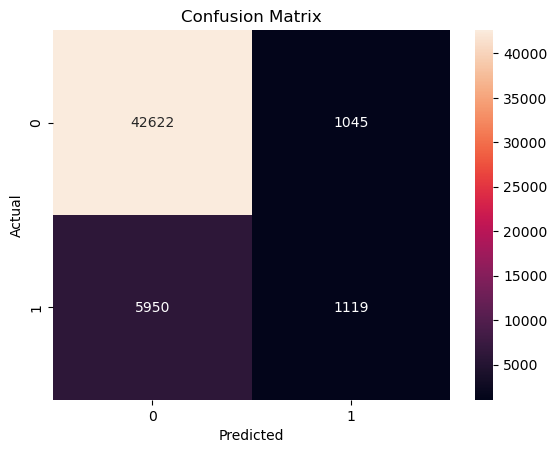

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [14]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_[0]
})

importance.sort_values(
    by="Coefficient",
    ascending=False,
    inplace=True
)

print(importance)

                 Feature  Coefficient
13               GenHlth     0.572245
3                    BMI     0.408314
18                   Age     0.382325
0                 HighBP     0.373808
1               HighChol     0.286321
2              CholCheck     0.237584
17                   Sex     0.125662
6   HeartDiseaseorAttack     0.065403
16              DiffWalk     0.047872
5                 Stroke     0.028458
11         AnyHealthcare     0.017834
12           NoDocbcCost     0.008698
4                 Smoker    -0.003966
9                Veggies    -0.006571
7           PhysActivity    -0.021168
14              MentHlth    -0.027460
19             Education    -0.030281
8                 Fruits    -0.033795
15              PhysHlth    -0.063425
20                Income    -0.105203
10     HvyAlcoholConsump    -0.181784


In [34]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
rf_pred = rf_model.predict(X_test)

print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

         0.0       0.88      0.97      0.92     43667
         1.0       0.49      0.18      0.26      7069

    accuracy                           0.86     50736
   macro avg       0.68      0.57      0.59     50736
weighted avg       0.82      0.86      0.83     50736



In [17]:
accuracy = accuracy_score(y_test, rf_pred)
print(accuracy)

0.8594094922737306


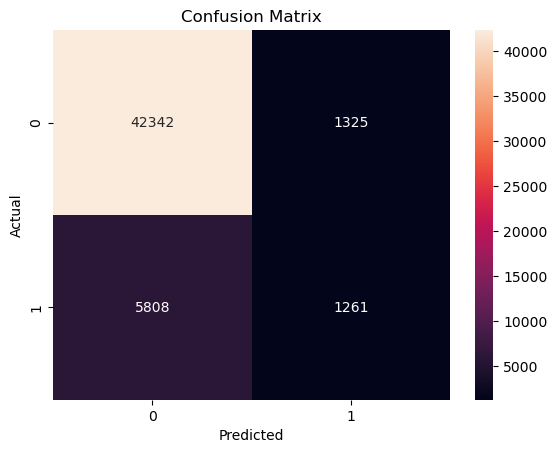

In [18]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [19]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

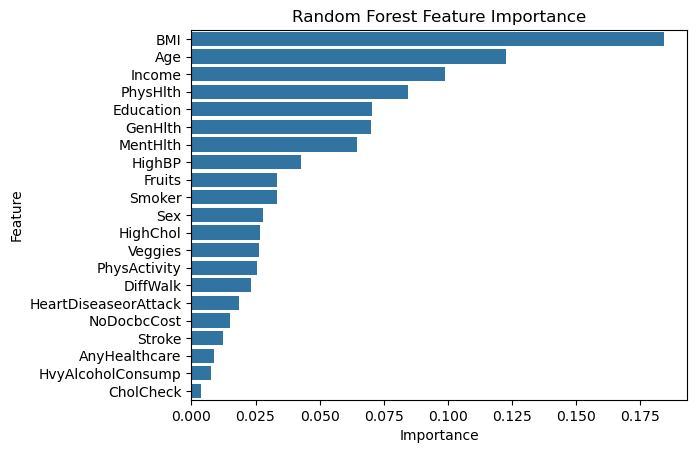

In [20]:
sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")

plt.show()

In [21]:
risk_scores = rf_model.predict_proba(X_test)[:,1]

In [22]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=42
)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=rf_model, 
    param_grid=param_grid, 
    cv=5, 
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best Score: 0.8659334611145452


In [23]:
rf_best_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

rf_best_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
rf_best_pred = rf_best_model.predict(X_test)

print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

         0.0       0.88      0.97      0.92     43667
         1.0       0.49      0.18      0.26      7069

    accuracy                           0.86     50736
   macro avg       0.68      0.57      0.59     50736
weighted avg       0.82      0.86      0.83     50736



In [26]:
accuracy = accuracy_score(y_test, rf_best_pred)
print(accuracy)

0.8648494165878272


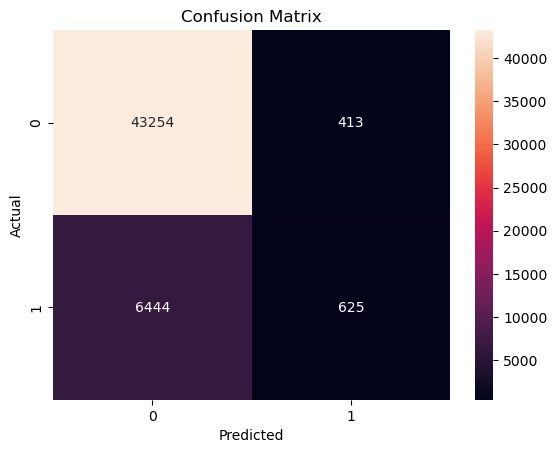

In [27]:
cm = confusion_matrix(y_test, rf_best_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Risk Analysis

In [36]:
risk_scores = rf_model.predict_proba(X_test)[:,1]
risk_scores

array([0.055, 0.45 , 0.   , ..., 0.   , 0.14 , 0.   ])

In [49]:
results = X_test.copy()
results["Outcome"] = y_test.copy()
results["RiskScore"] = risk_scores

results["RiskGroup"] = pd.cut(
    results["RiskScore"],
    bins=[0,0.3,0.7,1],
    include_lowest=True,
    labels=["Low", "Medium", "High"]
)

In [38]:
results["RiskGroup"]

128677       Low
225051    Medium
27174        Low
132371       Low
164896    Medium
           ...  
48574        Low
230352    Medium
134904       Low
1376         Low
69400        Low
Name: RiskGroup, Length: 50736, dtype: category
Categories (3, object): ['Low' < 'Medium' < 'High']

In [39]:
results["RiskGroup"].value_counts()
#Low = (41826) 82.4%
#Medium = (8560) 16.9%
#High= (350) 0.7%

RiskGroup
Low       41826
Medium     8560
High        350
Name: count, dtype: int64

In [40]:
high_risk = results[
    results["RiskGroup"] == "High"
]

In [41]:
high_risk.mean(numeric_only=True)
#Age 9 = 60 to 64 | Age 10 = 65 to 79 
#Edu 4 = College 1 year to 3 years| Edu 5 = College 4 years or more
#Income 5 = $25,000 to less than $35,000| 6 = $35,000 to less than $50,000

HighBP                   0.945714
HighChol                 0.897143
CholCheck                1.000000
BMI                     36.980000
Smoker                   0.491429
Stroke                   0.151429
HeartDiseaseorAttack     0.328571
PhysActivity             0.625714
Fruits                   0.648571
Veggies                  0.848571
HvyAlcoholConsump        0.000000
AnyHealthcare            0.997143
NoDocbcCost              0.068571
GenHlth                  3.774286
MentHlth                 5.151429
PhysHlth                11.065714
DiffWalk                 0.537143
Sex                      0.502857
Age                      9.660000
Education                4.831429
Income                   5.151429
RiskScore                0.764851
dtype: float64

In [42]:
low_risk = results[
    results["RiskGroup"] == "Low"
]

In [43]:
low_risk.mean(numeric_only=True)
#Tend to have lower BP and Chol
#PhysHealth and diffWalk lower
#YoungerAverage age (down 2 tiers)

HighBP                   0.335198
HighChol                 0.353058
CholCheck                0.957156
BMI                     27.313513
Smoker                   0.425023
Stroke                   0.024052
HeartDiseaseorAttack     0.053460
PhysActivity             0.791541
Fruits                   0.645890
Veggies                  0.825946
HvyAlcoholConsump        0.067350
AnyHealthcare            0.948429
NoDocbcCost              0.075145
GenHlth                  2.289700
MentHlth                 2.768039
PhysHlth                 3.092120
DiffWalk                 0.105293
Sex                      0.429183
Age                      7.679792
Education                5.142089
Income                   6.301822
RiskScore                0.079682
dtype: float64

In [44]:
feature_importance

,Feature,Importance
3,BMI,0.184123
18,Age,0.122429
20,Income,0.098747
15,PhysHlth,0.084610
19,Education,0.070320
13,GenHlth,0.070139
14,MentHlth,0.064511
0,HighBP,0.042603
8,Fruits,0.033205
4,Smoker,0.033193


In [45]:
low_risk.columns

Index(['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
       'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income',
       'RiskScore', 'RiskGroup'],
      dtype='object')

In [46]:
risk_compare = pd.DataFrame({
    'Low_risk': low_risk.mean(numeric_only=True),
    'High_risk':high_risk.mean(numeric_only=True)
})
risk_compare

,Low_risk,High_risk
HighBP,0.335198,0.945714
HighChol,0.353058,0.897143
CholCheck,0.957156,1.000000
BMI,27.313513,36.980000
Smoker,0.425023,0.491429
Stroke,0.024052,0.151429
HeartDiseaseorAttack,0.053460,0.328571
PhysActivity,0.791541,0.625714
Fruits,0.645890,0.648571
Veggies,0.825946,0.848571


Based on the findings those with a higher BMI tend to have a higher risk than than low-risk patients, this in turn suggest that those calssified as being obese have a higher risk of being diagnosis with diabetes.

In [47]:
feature_importance

,Feature,Importance
3,BMI,0.184123
18,Age,0.122429
20,Income,0.098747
15,PhysHlth,0.084610
19,Education,0.070320
13,GenHlth,0.070139
14,MentHlth,0.064511
0,HighBP,0.042603
8,Fruits,0.033205
4,Smoker,0.033193


BMI is the highest indicator of diabetes risk second to age, inidcating those with a higher BMI and who tend to be older are more at risk at being diagnosed with diabetes.

In [51]:
results.to_csv(
    "diabetes_risk_result.csv",
    index=False
)